Test Wallahi

In [1]:
#import the cleaned data.

#the real function will get the df fed as input from the clean function

import pandas as pd
import matplotlib.pyplot as plt
from clean_emi_data import clean_outages

save_path = 'data_output/outages_preprocessed.csv'

df = clean_outages()

✅ production outages has been cleaned and saved under data_output/scheduled_outages_utc12.csv ✅


In [20]:
df.head()

,Timestamp,NZ_G,NZ_H,NZ_T,NZ_W,UNKN,hour_bucket
0,2013-12-31 23:00:00,0.0,50.2,250.0,0.0,0.0,2013-12-31 23:00:00
1,2013-12-31 23:30:00,0.0,50.2,250.0,0.0,0.0,2014-01-01 00:00:00
2,2014-01-01 00:00:00,0.0,50.2,250.0,0.0,0.0,2014-01-01 00:00:00
3,2014-01-01 00:30:00,0.0,50.2,250.0,0.0,0.0,2014-01-01 01:00:00
4,2014-01-01 01:00:00,0.0,50.2,250.0,0.0,0.0,2014-01-01 01:00:00


In [ ]:
df['hour_bucket'] = (
    df['Timestamp'] + pd.Timedelta(minutes=30)
).dt.floor('h')

df_hourly_outages = (
    df
    .groupby('hour_bucket')
    .agg(
        datetime_utc12 = ('Timestamp', 'max'),
        outage_Gas_MW          = ('NZ_G',      'mean'),
        outage_Hyd_MW           = ('NZ_H',      'mean'),
        outage_Ter_MW        = ('NZ_T',      'mean'),
        outage_Win_MW           = ('NZ_W',      'mean'),
        outage_UNKN_MW           = ('UNKN',      'mean'),
    )
    .reset_index(drop=True)
    .sort_values('datetime_utc12')
    .reset_index(drop=True)
)

In [12]:
df_hourly_outages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108670 entries, 0 to 108669
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   datetime_utc12  108670 non-null  datetime64[ns]
 1   outage_Gas_MW   108670 non-null  float64       
 2   outage_Hyd_MW   108670 non-null  float64       
 3   outage_Ter_MW   108670 non-null  float64       
 4   outage_Win_MW   108670 non-null  float64       
 5   outage_UNKN_MW  108670 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 5.0 MB


In [18]:
df_hourly_outages.head()


,datetime_utc12,outage_Gas_MW,outage_Hyd_MW,outage_Ter_MW,outage_Win_MW,outage_UNKN_MW
0,2013-12-31 23:00:00,0.0,50.2,250.0,0.0,0.0
1,2014-01-01 00:00:00,0.0,50.2,250.0,0.0,0.0
2,2014-01-01 01:00:00,0.0,50.2,250.0,0.0,0.0
3,2014-01-01 02:00:00,0.0,50.2,250.0,0.0,0.0
4,2014-01-01 03:00:00,0.0,50.2,250.0,0.0,0.0


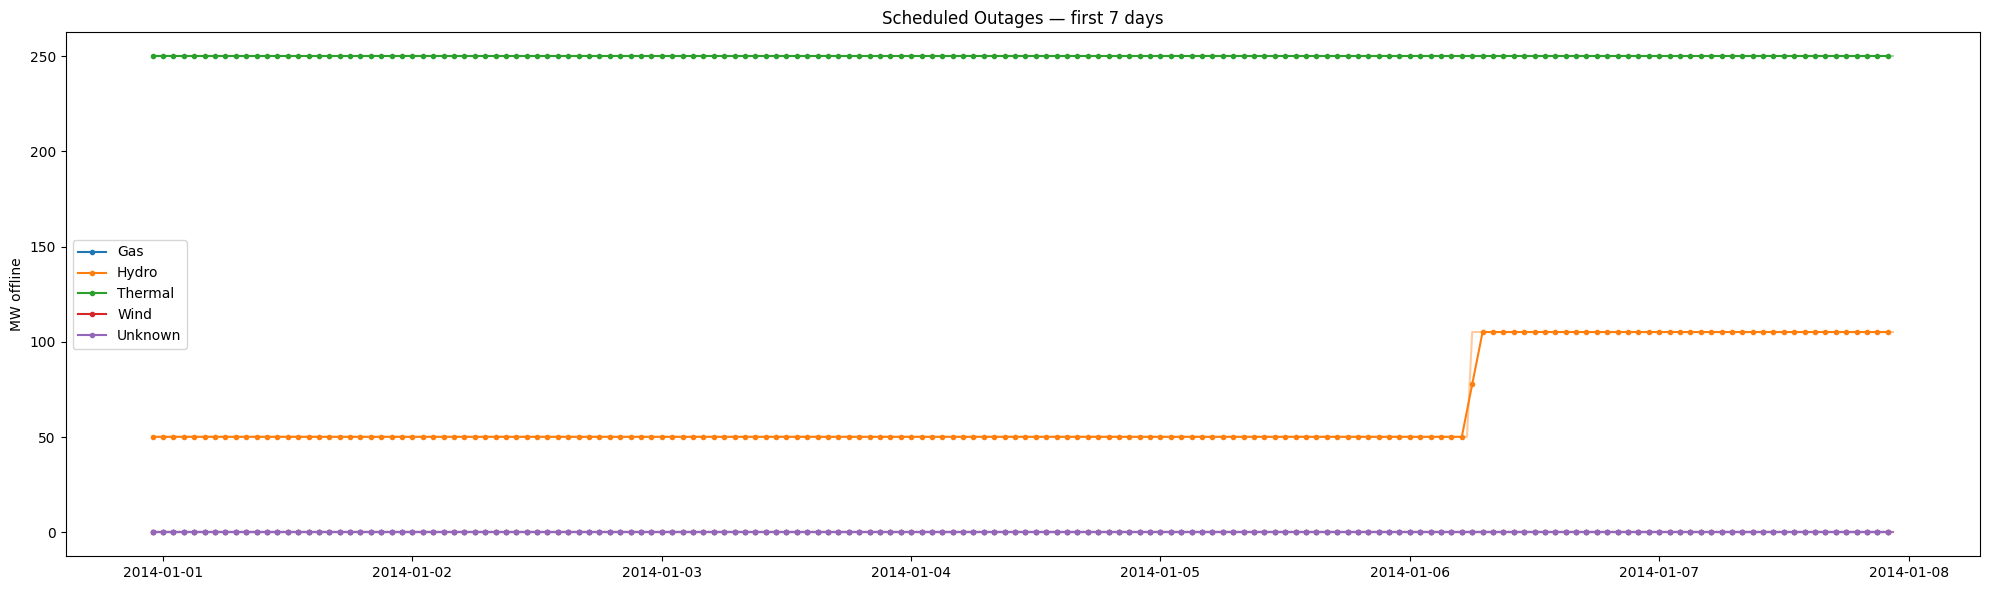

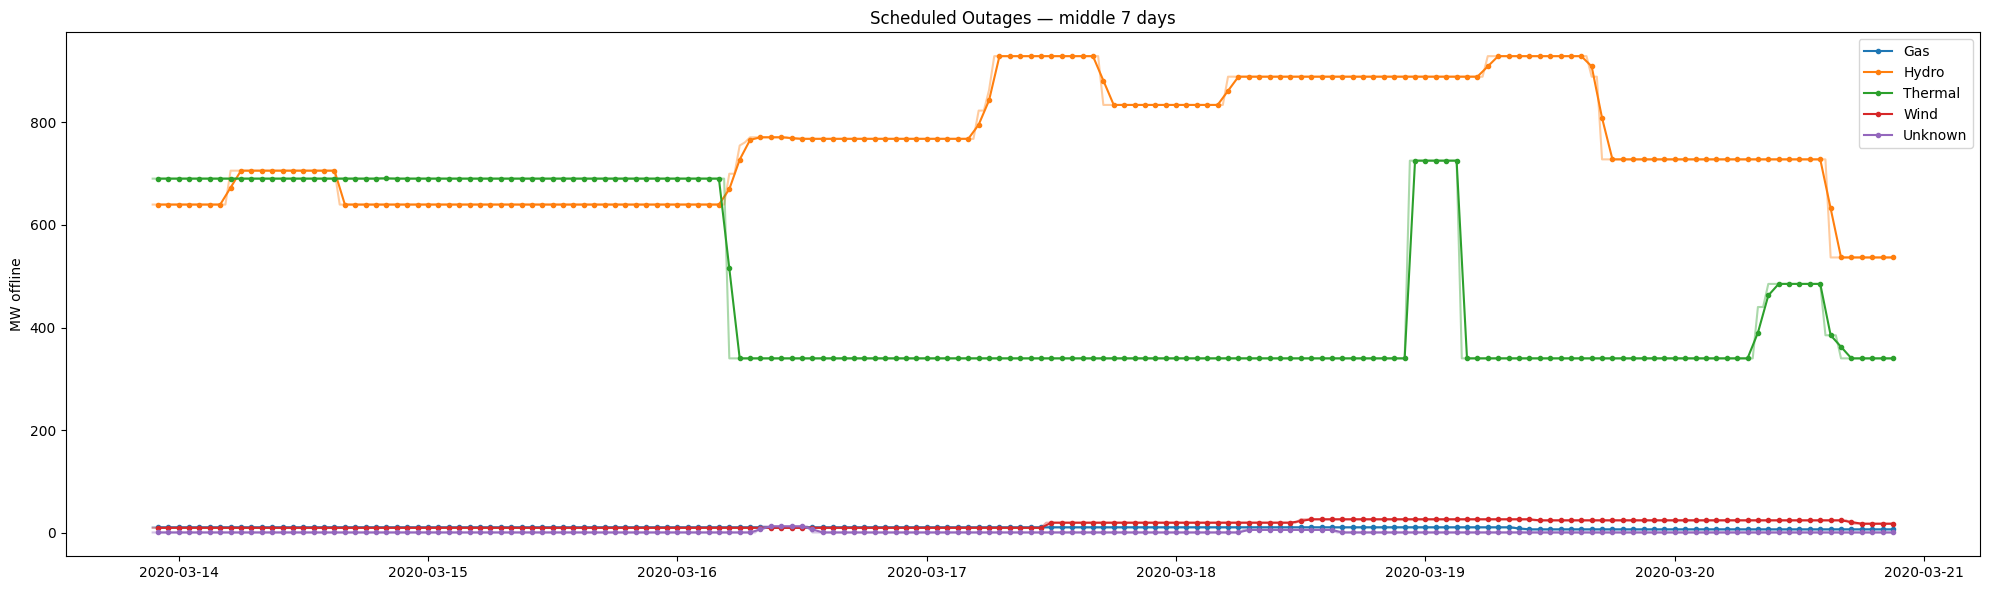

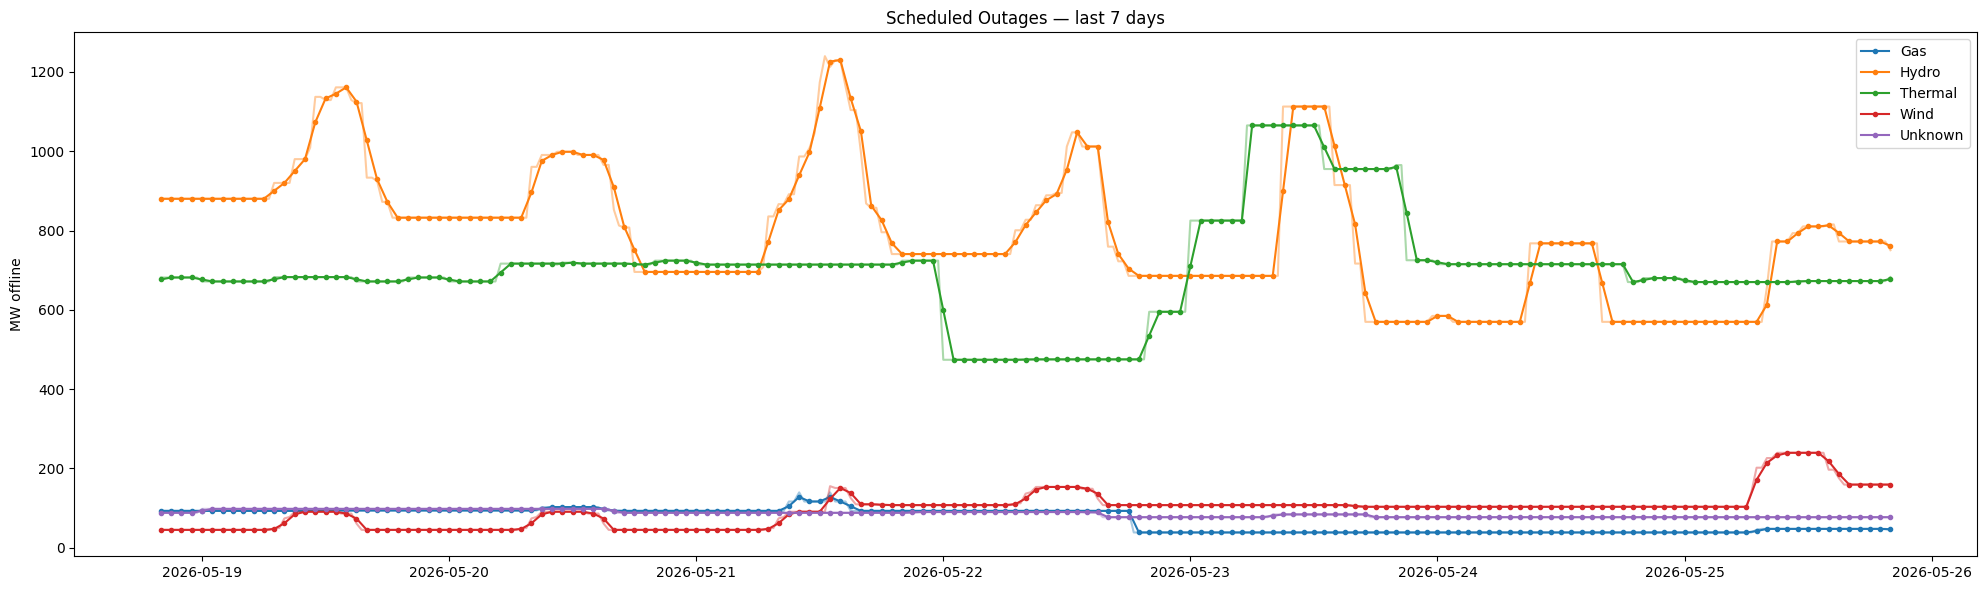

In [19]:
import matplotlib.pyplot as plt

def plot_window_outages(label, mask_hh, mask_h):
    fig, ax = plt.subplots(figsize=(20, 6))

    cols_hh = ['NZ_G',          'NZ_H',          'NZ_T',          'NZ_W',          'UNKN'          ]
    cols_h  = ['outage_Gas_MW', 'outage_Hyd_MW', 'outage_Ter_MW', 'outage_Win_MW', 'outage_UNKN_MW']
    labels  = ['Gas',           'Hydro',          'Thermal',       'Wind',           'Unknown'       ]

    for col_hh, col_h, lbl in zip(cols_hh, cols_h, labels):
        line, = ax.plot(df[mask_hh]['Timestamp'], df[mask_hh][col_hh], alpha=0.4)
        ax.plot(df_hourly_outages[mask_h]['datetime_utc12'], df_hourly_outages[mask_h][col_h],
                label=lbl, color=line.get_color(), marker='o', markersize=3)

    ax.set_title(f'Scheduled Outages — {label}')
    ax.set_ylabel('MW offline')
    ax.legend()
    plt.tight_layout()
    plt.show()

# First 7 days
mask_hh_start = df['Timestamp'] < df['Timestamp'].min() + pd.Timedelta(days=7)
mask_h_start  = df_hourly_outages['datetime_utc12'] < df_hourly_outages['datetime_utc12'].min() + pd.Timedelta(days=7)

# Middle
mid_hh = df['Timestamp'].min() + (df['Timestamp'].max() - df['Timestamp'].min()) / 2
mid_h  = df_hourly_outages['datetime_utc12'].min() + (df_hourly_outages['datetime_utc12'].max() - df_hourly_outages['datetime_utc12'].min()) / 2

mask_hh_mid = (df['Timestamp'] >= mid_hh) & (df['Timestamp'] < mid_hh + pd.Timedelta(days=7))
mask_h_mid  = (df_hourly_outages['datetime_utc12'] >= mid_h) & (df_hourly_outages['datetime_utc12'] < mid_h + pd.Timedelta(days=7))

# End
mask_hh_end = df['Timestamp'] >= df['Timestamp'].max() - pd.Timedelta(days=7)
mask_h_end  = df_hourly_outages['datetime_utc12'] >= df_hourly_outages['datetime_utc12'].max() - pd.Timedelta(days=7)

plot_window_outages('first 7 days',  mask_hh_start, mask_h_start)
plot_window_outages('middle 7 days', mask_hh_mid,   mask_h_mid)
plot_window_outages('last 7 days',   mask_hh_end,   mask_h_end)